# Behavior demo: watching an MLP learn a function

Here we train a tiny network (`1 -> 12 tanh -> 1 linear`) to approximate `sin(x)` and animate the whole run as a dashboard. Six panels, synced over training epochs:

1. **learning the function** &mdash; the target `sin(x)` vs the network's current output. Watch it morph from a rough guess into the curve.
2. **per-neuron contributions** &mdash; each hidden neuron's `weight * tanh(...)` curve. You see the individual building blocks arrange themselves and sum into the function. This is universal approximation, made visible.
3. **residual** &mdash; network minus target, so you see exactly where it's still wrong.
4. **loss** &mdash; mean squared error per epoch (log scale).
5. **gradient / weight magnitude** &mdash; training health: the gradient spikes then decays, the weights grow and settle.
6. a text readout of the current epoch, loss, and architecture.

Unlike the graph animation in `mechanism.ipynb`, this view is about the network's *behavior*, not the engine's internals.

In [1]:
import os, sys

# make the micrograd package importable when running from examples/
ROOT = os.path.abspath("..")
sys.path.insert(0, ROOT)
ASSETS = os.path.join(ROOT, "assets")
os.makedirs(ASSETS, exist_ok=True)

from micrograd.learn import fit_function, animate_fit

## Train and animate

`fit_function` trains the net and records a snapshot every so often; `animate_fit` renders those into the dashboard GIF. Training runs entirely on your scalar autograd engine, so it takes ~20s.

final loss: 0.00107


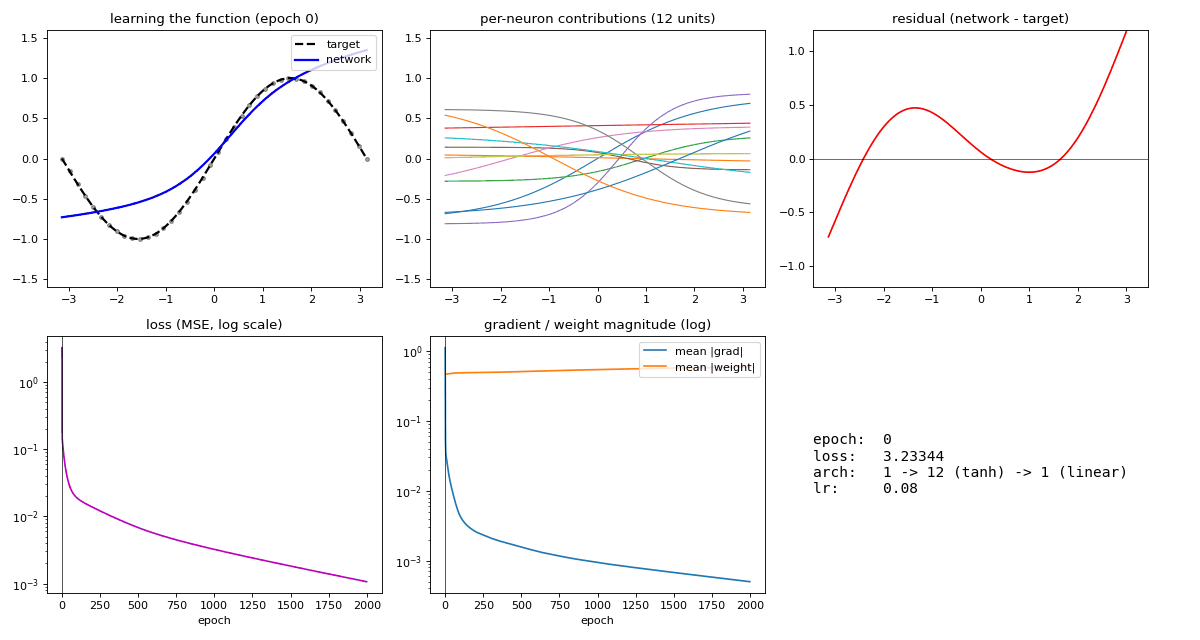

In [2]:
from IPython.display import Image

history = fit_function()              # defaults: sin(x), 1 -> 12 -> 1, 2000 epochs
print("final loss:", round(history["losses"][-1], 5))

gif_path = os.path.join(ASSETS, "learn_sin.gif")
animate_fit(history, gif_path)
Image(filename=gif_path)

## Try another function

Anything 1-D works. Pass a different `target` and `domain` (and widen the y-limits in `animate_fit` if the range is bigger than sin's).

In [3]:
# import math
# history = fit_function(target=lambda x: math.sin(2 * x) * 0.6, domain=(-math.pi, math.pi))
# animate_fit(history, os.path.join(ASSETS, "learn_other.gif"))
# Image(filename=os.path.join(ASSETS, "learn_other.gif"))